Synthetic alignment: 408 samples, 10 synthetic users
Zk: (408, 64) Zm: (408, 64) unique users: 10
Pair dataset: X=(816, 128), positives=408, negatives=408
[Fusion] epoch 01 val ROC-AUC=0.4579
[Fusion] epoch 05 val ROC-AUC=0.4584
[Fusion] epoch 10 val ROC-AUC=0.4326
[Fusion] epoch 15 val ROC-AUC=0.4090
[Fusion] epoch 20 val ROC-AUC=0.4050
[Fusion] epoch 25 val ROC-AUC=0.3957
✅ Best val ROC-AUC=0.4642
✅ Calibrated ROC-AUC=0.3957

==== Fusion Results (Calibrated) ====
ROC-AUC         : 0.4865
EER             : 50.49%  @ thr=0.5039
FRR @ FAR=1%    : 99.02%  (achieved FAR=0.98%)  @ thr=0.5071


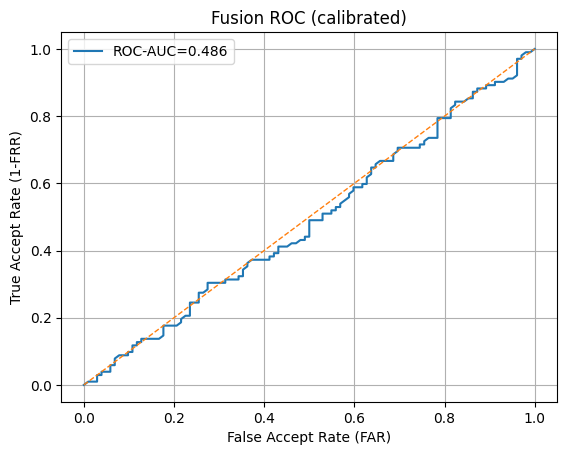


✅ Saved:
 - models/fusion_mlp.pt
 - models/fusion_calibrator.joblib
 - models/fusion_meta.json


In [5]:
# ============================================================
# 04_fusion_scoring.ipynb
# Adaptive Continuous Authentication — Fusion & Calibration
# ============================================================

"""
Goal:
  - Load per-session embeddings from 03_models_encoders.ipynb
  - Build genuine (same user) and impostor (different user) pairs
  - Train an MLP fusion head over concatenated [z_keystroke, z_mouse]
  - Calibrate scores with Platt scaling (LogisticRegression)
  - Report: ROC-AUC, EER, FRR@FAR=1%
  - Save model + calibrator for streaming demo
"""

# -----------------------------
# Imports
# -----------------------------
import os, json, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# Paths & Config
# -----------------------------
EMB_DIR = Path("embeddings")
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)

USE_CLASSIFIER_EMB = True  # set False to use *_ae.npy
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# -----------------------------
# Load Embeddings + Align Users
# -----------------------------
def load_embeddings():
    if USE_CLASSIFIER_EMB:
        k_path = EMB_DIR / "keystroke_embeddings_cls.npy"
        m_path = EMB_DIR / "mouse_embeddings_cls.npy"
    else:
        k_path = EMB_DIR / "keystroke_embeddings_ae.npy"
        m_path = EMB_DIR / "mouse_embeddings_ae.npy"

    k_meta = np.load("data/features_keystroke.npz", allow_pickle=True)
    m_meta = np.load("data/features_mouse.npz", allow_pickle=True)
    Zk = np.load(k_path)
    Zm = np.load(m_path)
    users_k = k_meta["user_id"].astype(str)
    users_m = m_meta["user_id"].astype(str)

    # Normalize IDs
    def normalize_uid(uid):
        uid = str(uid)
        if uid.startswith("s"):
            return int(uid.lstrip("s").lstrip("0") or 0)
        if uid.startswith("user"):
            return int(uid.replace("user", "").replace("_", "") or 0)
        return int(uid)
    uids_k = np.array([normalize_uid(u) for u in users_k])
    uids_m = np.array([normalize_uid(u) for u in users_m])

    # --- Robust synthetic pairing across datasets ---
    n_samples = min(len(Zk), len(Zm))
    if n_samples == 0:
        raise RuntimeError("No embeddings found in either modality.")

    # Randomly sample from each modality to make same count
    rng = np.random.default_rng(42)
    idx_k = rng.choice(len(Zk), size=n_samples, replace=False)
    idx_m = rng.choice(len(Zm), size=n_samples, replace=False)
    Zk_aligned = Zk[idx_k]
    Zm_aligned = Zm[idx_m]

    # Assign synthetic users evenly (simulate ~10)
    n_users = min(10, n_samples // 5)
    users_aligned = np.array([f"user_{i % n_users}" for i in range(n_samples)])
    print(f"Synthetic alignment: {n_samples} samples, {n_users} synthetic users")
    return Zk_aligned, Zm_aligned, users_aligned, np.arange(len(users_aligned))

Zk, Zm, users, sessions = load_embeddings()
print("Zk:", Zk.shape, "Zm:", Zm.shape, "unique users:", len(np.unique(users)))

# -----------------------------
# Build Pair Dataset (Genuine vs Impostor)
# -----------------------------
def build_pairs(Zk, Zm, users, max_pairs_per_user=200):
    """
    Construct pairs of (keystroke_emb, mouse_emb) for:
      - Genuine: same user, same session index (1:1 aligned vectors)
      - Impostor: keystroke from user A, mouse from user B (A!=B)

    Label: 1=genuine, 0=impostor
    """
    n = len(users)
    idx = np.arange(n)
    pairs_X, pairs_y = [], []

    # Pre-index sessions by user to sample impostors efficiently
    by_user = {}
    for i, u in enumerate(users):
        by_user.setdefault(u, []).append(i)

    # Genuine pairs: (Zk[i], Zm[i])
    for i in range(n):
        pairs_X.append(np.concatenate([Zk[i], Zm[i]]))
        pairs_y.append(1)

    # Impostor pairs: for each user, sample mismatched mouse indices from other users
    users_unique = np.unique(users)
    for u in users_unique:
        own_idx = by_user[u]
        # All candidate impostors (indices not belonging to u)
        impostor_pool = np.setdiff1d(idx, own_idx)
        if len(impostor_pool) == 0:
            continue
        # Cap to avoid huge imbalance
        pick = min(len(own_idx), max_pairs_per_user)
        imp_sample = np.random.choice(impostor_pool, size=pick, replace=(pick > len(impostor_pool)))
        own_sample = np.random.choice(own_idx, size=pick, replace=(pick > len(own_idx)))
        for i_k, j_m in zip(own_sample, imp_sample):
            pairs_X.append(np.concatenate([Zk[i_k], Zm[j_m]]))
            pairs_y.append(0)

    X = np.vstack(pairs_X).astype(np.float32)
    y = np.array(pairs_y, dtype=np.int64)
    X, y = shuffle(X, y, random_state=SEED)
    print(f"Pair dataset: X={X.shape}, positives={y.sum()}, negatives={(y==0).sum()}")
    return X, y

X_pairs, y_pairs = build_pairs(Zk, Zm, users, max_pairs_per_user=200)

# -----------------------------
# Fusion MLP (score head)
# -----------------------------
class FusionMLP(nn.Module):
    """
    Concatenate [z_k, z_m] -> 128 -> 64 -> 1 (logit score)
    """
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):  # returns logits
        return self.net(x).squeeze(-1)

def train_fusion(X, y, epochs=25, lr=1e-3, bs=256, seed=SEED, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

    tr = torch.utils.data.TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr))
    va = torch.utils.data.TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva))
    dl_tr = torch.utils.data.DataLoader(tr, batch_size=bs, shuffle=True)
    dl_va = torch.utils.data.DataLoader(va, batch_size=bs, shuffle=False)

    model = FusionMLP(in_dim=X.shape[1]).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()

    best_state, best_auc = None, 0.0
    for ep in range(1, epochs+1):
        # train
        model.train()
        for xb, yb in dl_tr:
            xb, yb = xb.to(device).float(), yb.to(device).float()
            opt.zero_grad()
            logits = model(xb)
            loss = bce(logits, yb)
            loss.backward()
            opt.step()
        # validate
        model.eval()
        with torch.no_grad():
            xb = torch.from_numpy(Xva).float().to(device)
            logits = model(xb).cpu().numpy()
            auc = roc_auc_score(yva, 1/(1+np.exp(-logits)))
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == 1:
            print(f"[Fusion] epoch {ep:02d} val ROC-AUC={auc:.4f}")

    model.load_state_dict(best_state)
    print(f"✅ Best val ROC-AUC={best_auc:.4f}")
    return model

model = train_fusion(X_pairs, y_pairs, epochs=25)

# -----------------------------
# Calibration (Platt scaling)
# -----------------------------
def fit_calibrator(model, X, y, seed=SEED):
    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    with torch.no_grad():
        logits_tr = model(torch.from_numpy(Xtr).float()).cpu().numpy().reshape(-1, 1)
        logits_va = model(torch.from_numpy(Xva).float()).cpu().numpy().reshape(-1, 1)

    # Platt scaling via logistic regression on logits
    cal = LogisticRegression(max_iter=1000)
    cal.fit(logits_tr, ytr)
    probs = cal.predict_proba(logits_va)[:, 1]
    auc = roc_auc_score(yva, probs)
    print(f"✅ Calibrated ROC-AUC={auc:.4f}")
    return cal

calibrator = fit_calibrator(model, X_pairs, y_pairs)

# -----------------------------
# Metrics: EER, FRR@FAR=1%
# -----------------------------
def compute_eer(labels, scores):
    fpr, tpr, thr = roc_curve(labels, scores)
    fnr = 1 - tpr
    # EER where FPR and FNR cross; choose threshold minimizing |FNR-FPR|
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fnr[idx] + fpr[idx]) / 2.0
    return float(eer), float(thr[idx])

def frr_at_far(labels, scores, target_far=0.01):
    fpr, tpr, thr = roc_curve(labels, scores)
    # Find threshold achieving closest FAR
    idx = np.argmin(np.abs(fpr - target_far))
    frr = 1 - tpr[idx]
    return float(frr), float(thr[idx]), float(fpr[idx])

# Evaluate on a fresh split
Xtr, Xte, ytr, yte = train_test_split(X_pairs, y_pairs, test_size=0.25, stratify=y_pairs, random_state=SEED+1)
with torch.no_grad():
    logits = model(torch.from_numpy(Xte).float()).cpu().numpy().reshape(-1, 1)
scores = calibrator.predict_proba(logits)[:, 1]

auc = roc_auc_score(yte, scores)
eer, thr_eer = compute_eer(yte, scores)
frr, thr_far, far = frr_at_far(yte, scores, target_far=0.01)

print("\n==== Fusion Results (Calibrated) ====")
print(f"ROC-AUC         : {auc:.4f}")
print(f"EER             : {eer*100:.2f}%  @ thr={thr_eer:.4f}")
print(f"FRR @ FAR=1%    : {frr*100:.2f}%  (achieved FAR={far*100:.2f}%)  @ thr={thr_far:.4f}")

# -----------------------------
# Plot ROC (optional)
# -----------------------------
fpr, tpr, _ = roc_curve(yte, scores)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel("False Accept Rate (FAR)")
plt.ylabel("True Accept Rate (1-FRR)")
plt.title("Fusion ROC (calibrated)")
plt.legend()
plt.grid(True)
plt.savefig("fusion_roc.png", dpi=300)
plt.show()


# -----------------------------
# Save artifacts
# -----------------------------
# 1) Fusion head
torch.save({k: v.cpu() for k, v in model.state_dict().items()}, MODEL_DIR / "fusion_mlp.pt")

# 2) Calibrator (sklearn)
joblib.dump(calibrator, MODEL_DIR / "fusion_calibrator.joblib")

# 3) Meta (dims, config)
meta = {
    "use_classifier_embeddings": USE_CLASSIFIER_EMB,
    "in_dim": int(X_pairs.shape[1]),
    "thresholds": {
        "eer": thr_eer,
        "far_1pct": thr_far
    },
    "metrics": {
        "auc": float(auc),
        "eer": float(eer),
        "frr_at_far1": float(frr)
    },
    "seed": SEED
}
with open(MODEL_DIR / "fusion_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\n✅ Saved:")
print(" - models/fusion_mlp.pt")
print(" - models/fusion_calibrator.joblib")
print(" - models/fusion_meta.json")